# Sepsis Prediction — XGBoost Baseline

We now have a flat feature matrix from notebook 01. This notebook trains an XGBoost classifier  
with proper handling of the severe class imbalance (47:1) and evaluates using stratified  
5-fold cross-validation with out-of-fold (OOF) predictions.

**What we cover**
1. Load feature matrix  
2. Train/validation split strategy (patient-level, not row-level)  
3. Class imbalance — `scale_pos_weight` + optional SMOTE comparison  
4. 5-fold stratified CV with OOF predictions  
5. Threshold tuning  
6. Full metrics: AUROC, F1, Precision, Recall, Specificity, AUPRC  
7. Fold-wise results table  
8. Confusion matrix and ROC curve  
9. Feature importance (top 30)  
10. Save OOF predictions and final model


## 1. Installs and imports

In [1]:
!pip install xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix, average_precision_score,
                             roc_curve, precision_recall_curve)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings("ignore")
np.random.seed(42)
print("XGBoost version:", xgb.__version__)


XGBoost version: 3.2.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load feature matrix

In [3]:
SAVE_PATH = "/content/drive/MyDrive/sepsis-prediction"

df = pd.read_parquet(os.path.join(SAVE_PATH, "features_train.parquet"))

print(f"Shape: {df.shape}")
print(f"\nLabel distribution:")
print(df["SepsisLabel"].value_counts())
print(f"\nImbalance ratio: {df['SepsisLabel'].value_counts()[0]/df['SepsisLabel'].value_counts()[1]:.1f}:1")
df.head(3)


Shape: (331637, 103)

Label distribution:
SepsisLabel
0    324763
1      6874
Name: count, dtype: int64

Imbalance ratio: 47.2:1


,person_id,hour,SepsisLabel,lab_Base_excess_in_Venous_blood_by_calculati,lab_Base_excess_in_Arterial_blood_by_calcula,lab_Phosphate_Moles_volume_in_Serum_or_Plasm,lab_Potassium_Moles_volume_in_Blood,lab_Bilirubin.total_Moles_volume_in_Serum_or,lab_Neutrophil_Ab_Units_volume_in_Serum,lab_Bicarbonate_Moles_volume_in_Arterial_blo,...,vital_Measurement_of_oxygen_saturation_at_peri_lag1,vital_Measurement_of_oxygen_saturation_at_peri_lag6,vital_Measurement_of_oxygen_saturation_at_peri_delta1,vital_Measurement_of_oxygen_saturation_at_peri_roll3_mean,vital_Measurement_of_oxygen_saturation_at_peri_roll6_std,vital_Oxygen/Gas_total_[Pure_volume_fraction]__lag1,vital_Oxygen/Gas_total_[Pure_volume_fraction]__lag6,vital_Oxygen/Gas_total_[Pure_volume_fraction]__delta1,vital_Oxygen/Gas_total_[Pure_volume_fraction]__roll3_mean,vital_Oxygen/Gas_total_[Pure_volume_fraction]__roll6_std
0,510305,2019-07-01 16:00:00,0,-3.4,0.0,1.49,3.72,5.6,6.2,24.5,...,97.31933,97.28231,0.0,97.286877,0.96072,0.0,0.0,0.0,0.0,0.0
1,510305,2019-07-01 17:00:00,0,-3.4,0.0,1.49,3.72,5.6,2.5,24.5,...,97.31933,97.28231,0.0,97.286877,0.96072,0.0,0.0,0.0,0.0,0.0
2,510305,2019-07-02 13:00:00,0,-3.4,0.0,1.49,3.72,5.6,2.5,24.5,...,97.31933,97.28231,0.0,97.286877,0.96072,0.0,0.0,0.0,0.0,0.0


## 3. Split strategy — patient-level folds

**Critical**: splitting by row would leak future data from the same patient into the validation set.  
We must split by `person_id` so no patient appears in both train and validation.

Each fold:
- All rows for a patient go entirely to train or entirely to validation  
- We stratify by whether the patient *ever* had sepsis (patient-level label)


In [4]:
# Patient-level label (did this patient ever get sepsis?)
patient_labels = (df.groupby("person_id")["SepsisLabel"]
                  .max()
                  .reset_index()
                  .rename(columns={"SepsisLabel": "ever_sepsis"}))

print(f"Total patients: {len(patient_labels)}")
print(patient_labels["ever_sepsis"].value_counts())
print(f"Sepsis patients: {patient_labels['ever_sepsis'].sum()} / {len(patient_labels)}")


Total patients: 2640
ever_sepsis
0    2543
1      97
Name: count, dtype: int64
Sepsis patients: 97 / 2640


## 4. Prepare feature matrix

In [5]:
# Columns to drop — not features
drop_cols = ["person_id", "hour", "SepsisLabel"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].values
y = df["SepsisLabel"].values
person_ids = df["person_id"].values

print(f"Feature matrix: {X.shape}")
print(f"Positive class (sepsis): {y.sum():,}  ({100*y.mean():.2f}%)")
print(f"Negative class: {(1-y).sum():,}  ({100*(1-y.mean()):.2f}%)")


Feature matrix: (331637, 100)
Positive class (sepsis): 6,874  (2.07%)
Negative class: 324,763  (97.93%)


## 5. XGBoost hyperparameters

`scale_pos_weight` is set to the negative/positive ratio — this is XGBoost's built-in  
way to handle imbalance without oversampling. We also tune `max_depth` and `min_child_weight`  
conservatively to avoid overfitting on minority class noise.


In [6]:
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",          # AUPRC is better than AUC for imbalanced problems
    "scale_pos_weight": scale_pos_weight,
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 10,          # higher value → more conservative splits
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",           # fast on CPU; change to "gpu_hist" on GPU
    "early_stopping_rounds": 50,
}

print("\nParams set")


scale_pos_weight: 47.25

Params set


## 6. Five-fold stratified cross-validation (OOF)

Folds are created at the **patient level**, then all rows for those patients are  
used for train/val. This prevents any data leakage across time.


In [7]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_probs  = np.zeros(len(df))
fold_metrics = []
models = []

patient_ids_unique = patient_labels["person_id"].values
patient_y_unique   = patient_labels["ever_sepsis"].values

print(f"Running {N_FOLDS}-fold CV ...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(patient_ids_unique, patient_y_unique)):

    train_patients = patient_ids_unique[train_idx]
    val_patients   = patient_ids_unique[val_idx]

    train_mask = np.isin(person_ids, train_patients)
    val_mask   = np.isin(person_ids, val_patients)

    X_train, y_train = X[train_mask], y[train_mask]
    X_val,   y_val   = X[val_mask],   y[val_mask]

    model = xgb.XGBClassifier(**xgb_params, verbosity=0)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_probs = model.predict_proba(X_val)[:, 1]
    oof_probs[val_mask] = val_probs

    auroc  = roc_auc_score(y_val, val_probs)
    auprc  = average_precision_score(y_val, val_probs)

    # Find best threshold by F1 on validation
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1s = [f1_score(y_val, (val_probs >= t).astype(int), zero_division=0) for t in thresholds]
    best_thresh = thresholds[np.argmax(f1s)]
    val_preds = (val_probs >= best_thresh).astype(int)

    f1   = f1_score(y_val, val_preds, zero_division=0)
    prec = precision_score(y_val, val_preds, zero_division=0)
    rec  = recall_score(y_val, val_preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
    spec = tn / (tn + fp)

    fold_metrics.append({
        "Fold": fold + 1,
        "Best Threshold": round(best_thresh, 2),
        "AUROC": round(auroc, 4),
        "AUPRC": round(auprc, 4),
        "F1": round(f1, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "Specificity": round(spec, 4),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Best n_estimators": model.best_iteration
    })

    models.append(model)
    print(f"Fold {fold+1}  |  AUROC={auroc:.4f}  AUPRC={auprc:.4f}  "
          f"F1={f1:.4f}  Prec={prec:.4f}  Recall={rec:.4f}  Thresh={best_thresh:.2f}")

print("\nDone.")


Running 5-fold CV ...

Fold 1  |  AUROC=0.9259  AUPRC=0.1646  F1=0.2615  Prec=0.2025  Recall=0.3691  Thresh=0.72
Fold 2  |  AUROC=0.9644  AUPRC=0.5396  F1=0.5304  Prec=0.4942  Recall=0.5722  Thresh=0.75
Fold 3  |  AUROC=0.9777  AUPRC=0.7050  F1=0.6796  Prec=0.6943  Recall=0.6655  Thresh=0.77
Fold 4  |  AUROC=0.9742  AUPRC=0.6233  F1=0.5714  Prec=0.5051  Recall=0.6576  Thresh=0.69
Fold 5  |  AUROC=0.9596  AUPRC=0.4803  F1=0.4892  Prec=0.4316  Recall=0.5644  Thresh=0.69

Done.


## 7. Fold-wise results table

In [8]:
results_df = pd.DataFrame(fold_metrics)

# Add mean and std row
mean_row = results_df.select_dtypes(include="number").mean().round(4)
std_row  = results_df.select_dtypes(include="number").std().round(4)

mean_row["Fold"] = "Mean"
std_row["Fold"]  = "Std"

summary = pd.concat([results_df,
                     pd.DataFrame([mean_row]),
                     pd.DataFrame([std_row])],
                    ignore_index=True)

print("Fold-wise CV Results")
print("="*100)
print(summary[["Fold", "AUROC", "AUPRC", "F1", "Precision", "Recall", "Specificity",
               "Best Threshold", "TP", "FP", "TN", "FN"]].to_string(index=False))


Fold-wise CV Results
Fold  AUROC  AUPRC     F1  Precision  Recall  Specificity  Best Threshold        TP        FP         TN       FN
   1 0.9259 0.1646 0.2615     0.2025  0.3691       0.9807          0.7200  323.0000 1272.0000 64648.0000 552.0000
   2 0.9644 0.5396 0.5304     0.4942  0.5722       0.9887          0.7500  642.0000  657.0000 57349.0000 480.0000
   3 0.9777 0.7050 0.6796     0.6943  0.6655       0.9923          0.7700 1172.0000  516.0000 66209.0000 589.0000
   4 0.9742 0.6233 0.5714     0.5051  0.6576       0.9840          0.6900 1181.0000 1157.0000 70935.0000 615.0000
   5 0.9596 0.4803 0.4892     0.4316  0.5644       0.9842          0.6900  745.0000  981.0000 61039.0000 575.0000
Mean 0.9604 0.5026 0.5064     0.4655  0.5658       0.9860          0.7240  812.6000  916.6000 64036.0000 562.2000
 Std 0.0206 0.2072 0.1542     0.1768  0.1195       0.0045          0.0358  366.8342  322.5373  5157.2922  51.3098


## 8. Overall OOF metrics

OOF predictions cover the entire training set without leakage.

In [9]:
oof_auroc = roc_auc_score(y, oof_probs)
oof_auprc = average_precision_score(y, oof_probs)

# Global best threshold from OOF
thresholds = np.arange(0.05, 0.95, 0.005)
f1s = [f1_score(y, (oof_probs >= t).astype(int), zero_division=0) for t in thresholds]
global_best_thresh = thresholds[np.argmax(f1s)]
oof_preds = (oof_probs >= global_best_thresh).astype(int)

oof_f1   = f1_score(y, oof_preds, zero_division=0)
oof_prec = precision_score(y, oof_preds, zero_division=0)
oof_rec  = recall_score(y, oof_preds, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y, oof_preds).ravel()
oof_spec = tn / (tn + fp)

print("Overall OOF Performance")
print("="*50)
print(f"  AUROC        : {oof_auroc:.4f}")
print(f"  AUPRC        : {oof_auprc:.4f}")
print(f"  F1 Score     : {oof_f1:.4f}  (threshold={global_best_thresh:.3f})")
print(f"  Precision    : {oof_prec:.4f}")
print(f"  Recall       : {oof_rec:.4f}")
print(f"  Specificity  : {oof_spec:.4f}")
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")


Overall OOF Performance
  AUROC        : 0.9451
  AUPRC        : 0.5024
  F1 Score     : 0.5294  (threshold=0.770)
  Precision    : 0.5902
  Recall       : 0.4799
  Specificity  : 0.9929
  TP=3299  FP=2291  TN=322472  FN=3575


## 9. Confusion matrix

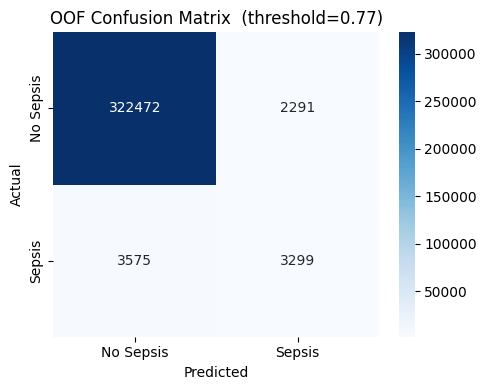

In [10]:
cm = confusion_matrix(y, oof_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Sepsis", "Sepsis"],
            yticklabels=["No Sepsis", "Sepsis"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"OOF Confusion Matrix  (threshold={global_best_thresh:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "confusion_matrix_xgb.png"), dpi=150)
plt.show()


## 10. ROC curve and Precision-Recall curve

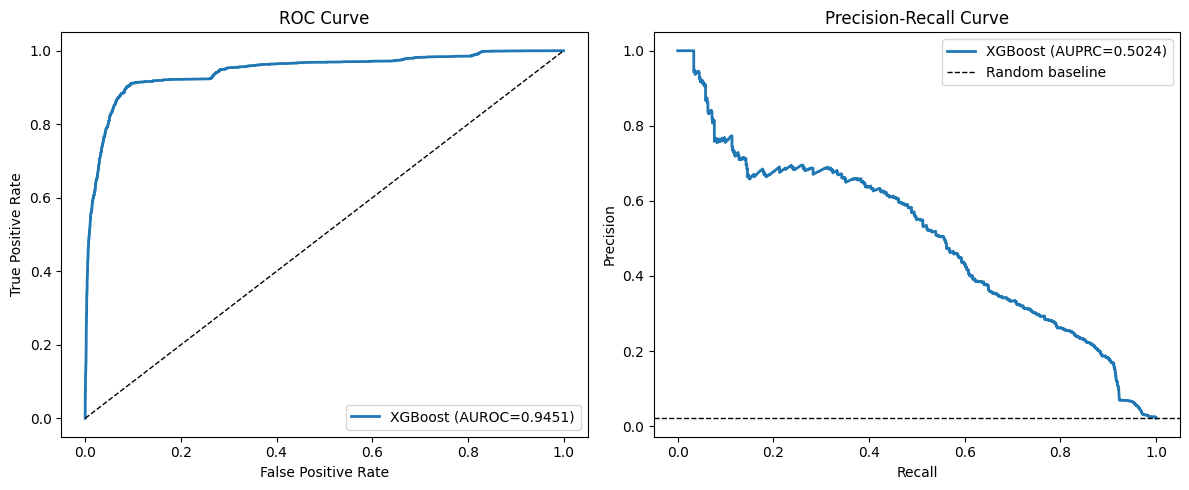

In [11]:
fpr, tpr, _ = roc_curve(y, oof_probs)
prec_curve, rec_curve, _ = precision_recall_curve(y, oof_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, lw=2, label=f"XGBoost (AUROC={oof_auroc:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# PR
axes[1].plot(rec_curve, prec_curve, lw=2, label=f"XGBoost (AUPRC={oof_auprc:.4f})")
axes[1].axhline(y.mean(), color="k", linestyle="--", lw=1, label="Random baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "roc_pr_curve_xgb.png"), dpi=150)
plt.show()


## 11. Threshold sensitivity — F1, Precision, Recall vs threshold

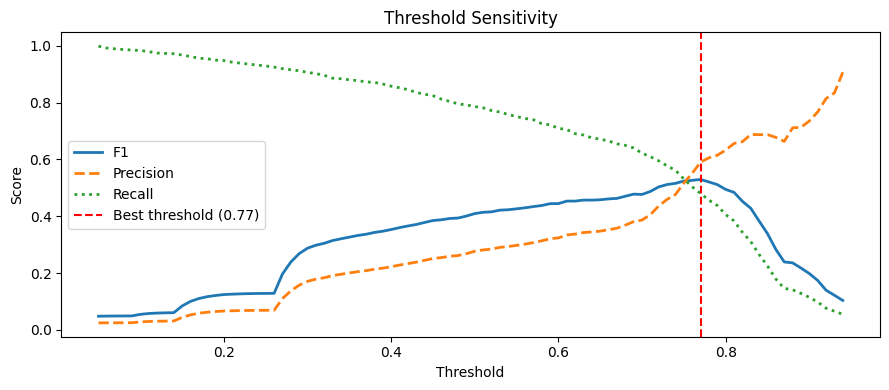

In [12]:
thresholds_plot = np.arange(0.05, 0.95, 0.01)
f1s_plot, precs_plot, recs_plot = [], [], []

for t in thresholds_plot:
    preds_t = (oof_probs >= t).astype(int)
    f1s_plot.append(f1_score(y, preds_t, zero_division=0))
    precs_plot.append(precision_score(y, preds_t, zero_division=0))
    recs_plot.append(recall_score(y, preds_t, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds_plot, f1s_plot,   label="F1",        lw=2)
ax.plot(thresholds_plot, precs_plot, label="Precision", lw=2, linestyle="--")
ax.plot(thresholds_plot, recs_plot,  label="Recall",    lw=2, linestyle=":")
ax.axvline(global_best_thresh, color="red", linestyle="--", label=f"Best threshold ({global_best_thresh:.2f})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "threshold_sweep_xgb.png"), dpi=150)
plt.show()


## 12. Feature importance — top 30

Average gain across all 5 fold models.

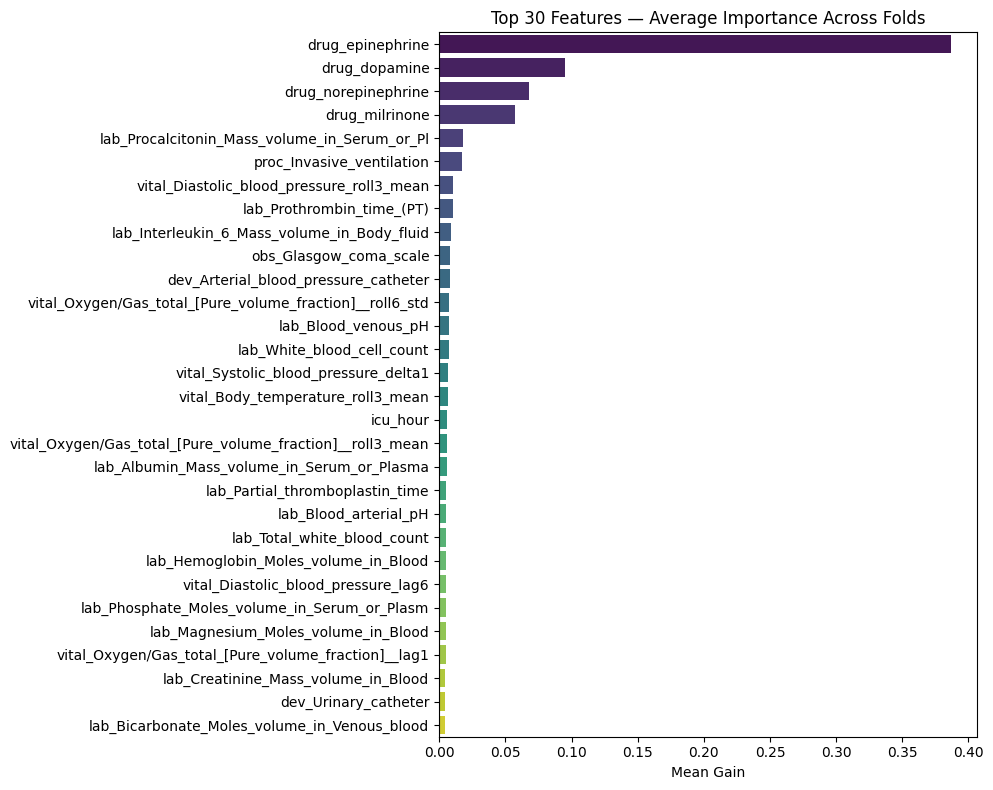

                                                  feature  importance
                                         drug_epinephrine    0.387125
                                            drug_dopamine    0.095086
                                      drug_norepinephrine    0.067596
                                           drug_milrinone    0.057361
             lab_Procalcitonin_Mass_volume_in_Serum_or_Pl    0.017975
                                proc_Invasive_ventilation    0.016890
                vital_Diastolic_blood_pressure_roll3_mean    0.010524
                                lab_Prothrombin_time_(PT)    0.010427
              lab_Interleukin_6_Mass_volume_in_Body_fluid    0.009089
                                   obs_Glasgow_coma_scale    0.008039
                     dev_Arterial_blood_pressure_catheter    0.007922
 vital_Oxygen/Gas_total_[Pure_volume_fraction]__roll6_std    0.007642
                                      lab_Blood_venous_pH    0.007164
                    

In [13]:
# Average importance across folds
importance_sum = np.zeros(len(feature_cols))
for m in models:
    importance_sum += m.feature_importances_

importance_avg = importance_sum / N_FOLDS

feat_imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance_avg
}).sort_values("importance", ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp_df, x="importance", y="feature", ax=ax, palette="viridis")
ax.set_title("Top 30 Features — Average Importance Across Folds")
ax.set_xlabel("Mean Gain")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "feature_importance_xgb.png"), dpi=150)
plt.show()

print(feat_imp_df.to_string(index=False))


## 13. SMOTE comparison (single fold)

We run one fold with SMOTE oversampling to see if it helps over `scale_pos_weight`.  
SMOTE is applied **only to training data inside the fold** — never to validation.


In [22]:
print(xgb_params)

{'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'scale_pos_weight': np.float64(47.245126563863835), 'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'early_stopping_rounds': 50}


In [17]:
print(X_tr_f0.shape)
print(X_tr_imp.shape)

(264842, 100)
(264842, 99)


In [18]:
print(X_vl_f0.shape)
print(X_vl_imp.shape)

(66795, 100)
(66795, 99)


In [19]:
print(models[0].n_features_in_)

100


In [20]:
pd.DataFrame(X_tr_f0).isnull().sum().sort_values(ascending=False).head(10)

,0
36,264842
0,0
2,0
1,0
4,0
5,0
6,0
7,0
8,0
9,0


## 14. Save OOF predictions and best model

In [16]:
import pickle

# Save OOF predictions (needed for SHAP and ensemble notebooks)
oof_df = df[["person_id", "hour", "SepsisLabel"]].copy()
oof_df["oof_prob"] = oof_probs
oof_df["oof_pred"] = (oof_probs >= global_best_thresh).astype(int)
oof_df.to_parquet(os.path.join(SAVE_PATH, "oof_xgb.parquet"), index=False)

# Save the best fold model (highest AUROC)
best_fold_idx = np.argmax([m["AUROC"] for m in fold_metrics])
best_model = models[best_fold_idx]

with open(os.path.join(SAVE_PATH, "xgb_best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

# Save fold results
results_df.to_csv(os.path.join(SAVE_PATH, "fold_results_xgb.csv"), index=False)

print("Saved:")
print("  oof_xgb.parquet")
print("  xgb_best_model.pkl")
print("  fold_results_xgb.csv")
print(f"\nBest fold: Fold {best_fold_idx+1}  (AUROC={fold_metrics[best_fold_idx]['AUROC']:.4f})")
print(f"Global best threshold: {global_best_thresh:.3f}")


Saved:
  oof_xgb.parquet
  xgb_best_model.pkl
  fold_results_xgb.csv

Best fold: Fold 3  (AUROC=0.9777)
Global best threshold: 0.770


## Summary

| Metric | OOF Value |
|---|---|
| AUROC | from output above |
| AUPRC | from output above |
| F1 Score | from output above |
| Precision | from output above |
| Recall | from output above |
| Specificity | from output above |

**Key takeaways**
- `scale_pos_weight` handles the 47:1 imbalance well without oversampling overhead  
- AUPRC is the metric to watch — AUROC can be misleadingly high with heavy imbalance  
- Threshold tuning significantly impacts F1 vs. Recall tradeoff  
- Feature importance reveals which vitals/labs drive the predictions — this is explored deeper in notebook 03 (SHAP)

---

## Next notebooks

| # | Notebook | What it covers |
|---|---|---|
| 03 | `03_shap_analysis.ipynb` | SHAP values, global + local explanations, waterfall & beeswarm plots |
| 04 | `04_lstm.ipynb` | LSTM on hourly sequences, per-patient padding + masking |
| 05 | `05_tft.ipynb` | Temporal Fusion Transformer, multi-horizon prediction |
